# GeneralRFM and Fisheye Coordinates

## Author: Zach Etienne

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook builds a two-transition fisheye coordinate map, visualizes how
raw grid radius maps to physical radius, and validates the generated
GeneralRFM support functions.

Navigation: [Index][index] | Previous: [Curvilinear Boundary Conditions][prev]
| Next: [Multicoordinate Wave Project][next]

[index]: ../index.ipynb
[prev]: curvilinear_boundary_conditions.ipynb
[next]: ../3-wave_equation/wave_equation_multicoordinates.ipynb

### Required Reading

- [Reference-Metric Applications](reference_metric_applications.ipynb)
- [Curvilinear Boundary Conditions](curvilinear_boundary_conditions.ipynb)

### NRPy Source Code

- [Fisheye map construction][fisheye-source]: builds the symbolic map and
  induced reference metric.
- [GeneralRFM precompute support][precompute-source]: registers generated
  precompute support for GeneralRFM coordinate systems.
- [GeneralRFM inverse-coordinate support][inverse-source]: registers
  generated Cartesian-to-coordinate support.
- [Fisheye physical-parameter support][params-source]: registers generated
  conversion from physical transition parameters to fisheye parameters.

[fisheye-source]: https://github.com/nrpy/nrpy/blob/main/nrpy/equations/generalrfm/fisheye.py
[precompute-source]: https://github.com/nrpy/nrpy/blob/main/nrpy/infrastructures/BHaH/generalrfm_precompute.py
[inverse-source]: https://github.com/nrpy/nrpy/blob/main/nrpy/infrastructures/BHaH/generalrfm_cart_to_xx.py
[params-source]: https://github.com/nrpy/nrpy/blob/main/nrpy/infrastructures/BHaH/fisheye/phys_params_to_fisheye.py

# Table of Contents

1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Notation and C-Function Structure](#Notation-and-C-Function-Structure)
1. [Step 1](#Step-1:-Build-the-Fisheye-Map): Build symbolic map metadata.
1. [Step 2](#Step-2:-Inspect-the-Registered-GeneralRFM-Map): Inspect provider.
1. [Step 3](#Step-3:-Sample-and-Plot-the-Radius-Map): Plot radial stretching.
1. [Validation Check](#Validation-Check): Validate metric components.
1. [Step 4](#Step-4:-Validate-Generated-Support-Functions): Validate support.
1. [Learning Check](#Learning-Check)
1. [Continue](#Continue)

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **GeneralRFM:** NRPy's mechanism for registering a custom reference-metric
  coordinate map.
- **Reference metric:** the coordinate-system geometry used as the baseline
  for curvilinear calculations.
- **Fisheye coordinates:** a smooth coordinate map that changes grid spacing
  with radius.
- **Raw Cartesian coordinates:** the numerical grid coordinates `xx[i]`.
- **Raw radius:** the coordinate radius computed from the raw coordinates.
- **Physical radius:** the radius interpreted as distance in the modeled
  space.
- **Plateau factor:** a nearly constant radial stretching factor away from a
  transition.
- **Transition center:** the raw radius where a stretching change is centered.
- **Transition width:** the radial scale over which the stretching changes.
- **Global scale factor:** the final multiplier applied to the physical radius.
- **BHaH:** the BlackHoles@Home infrastructure target used by generated NRPy
  C projects.
- **CodeParameter:** a runtime setting read by generated C code.
- **CFunction registry:** the `CFunction_dict` dictionary that stores
  generated C functions.
- **Coordinate wrapper:** metadata tying a generated C function to a specific
  coordinate system.
- **Precompute support:** generated code that stores coordinate-only metric
  data for reuse.
- **Inverse-map support:** generated code that maps Cartesian coordinates back
  to the custom coordinates.

# Notation and C-Function Structure
### [Back to [top](#Table-of-Contents)]

This notebook uses three raw Cartesian coordinates `xx[0]`, `xx[1]`, and
`xx[2]`. The raw radius is

$$
r = \sqrt{xx[0]^2 + xx[1]^2 + xx[2]^2}.
$$

The implementation in `fisheye.py` uses a radial map from raw Cartesian
coordinates to physical Cartesian coordinates:

$$
Cart^i = \lambda(r) xx^i, \qquad \lambda(r) = \frac{\bar r(r)}{r}.
$$

For two transitions, the unscaled fisheye radius has the form

$$
\bar r =
a_2 r +
\sum_{i=1}^{2}
\frac{s_i(a_{i-1} - a_i)}{2\tanh(R_i/s_i)}
\log\left[
\frac{\cosh((R_i + r)/s_i)}
     {\cosh((r - R_i)/s_i)}
\right].
$$

The physical radius is `c` times this expression:

$$
r_{\rm phys} = c\bar r.
$$

| Parameter | Role | What to inspect |
| --- | --- | --- |
| `a_i` | plateau stretch factors | physical/raw ratio |
| `R_i` | transition centers | where slope changes |
| `s_i` | transition widths | smoothness of change |
| `c` | global scale factor | final radius scale |

The induced reference metric is

$$
\hat{\gamma}_{ij}
= \sum_k \frac{\partial x^k}{\partial q^i}
         \frac{\partial x^k}{\partial q^j}.
$$

Generated C functions have this structure:

```c
/*
 * Description of what the function computes.
 */
return_type function_name(parameter_list) {
    local_declarations;
    assignments_or_algorithm;
}
```

In the generated metadata inspected below, `cfunc_type` is the return type,
`name` is the function name, `params` is the complete parameter list,
`includes` lists required headers, and `body` contains the generated algorithm.

# Step 1: Build the Fisheye Map
### [Back to [top](#Table-of-Contents)]

The next cell builds a two-transition fisheye map. The output lists the raw
coordinate variables and symbolic parameters that generated code later stores
or reads as coordinate parameters.

Inspect the output for:

- transition count;
- raw coordinate symbols;
- plateau factors;
- transition centers and widths;
- global scale factor.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

import nrpy.reference_metric as refmetric
from nrpy.equations.generalrfm import fisheye


logging.getLogger("matplotlib").setLevel(logging.WARNING)
fisheye_map = fisheye.build_fisheye(2)
print("transitions:", fisheye_map.num_transitions)
print("raw coordinates:", fisheye_map.xx)
print("plateau factors:", fisheye_map.a_list)
print("transition centers:", fisheye_map.R_list)
print("transition widths:", fisheye_map.s_list)
print("scale factor:", fisheye_map.c)

transitions: 2
raw coordinates: [xx0, xx1, xx2]
plateau factors: [fisheye_a0, fisheye_a1, fisheye_a2]
transition centers: [fisheye_R1, fisheye_R2]
transition widths: [fisheye_s1, fisheye_s2]
scale factor: fisheye_c


# Step 2: Inspect the Registered GeneralRFM Map
### [Back to [top](#Table-of-Contents)]

GeneralRFM registers the custom map so the reference-metric system can treat
it like a named coordinate system. The full symbolic map is large, so this
cell prints concept-bearing metadata and the complete set of fisheye
parameters in `lambda(r)`.

In [2]:
raw_radius = sp.sqrt(sum(coord**2 for coord in fisheye_map.xx))
lambda_expr = sp.simplify(fisheye_map.rbar_unscaled / raw_radius)
rfm = refmetric.reference_metric["GeneralRFM_fisheyeN2"]
print("map structure: Cart[i] = lambda(r) * xx[i]")
print("lambda(r) free parameters:")
for symbol in sorted(lambda_expr.free_symbols, key=str):
    if str(symbol).startswith("fisheye_"):
        print(" ", symbol)
print("reference metric:", rfm.CoordSystem)
print("provider:", rfm.general_rfm_provider_name)
print("provider metadata:", rfm.general_rfm_provider_meta)

Setting up reference_metric[GeneralRFM_fisheyeN2]...


map structure: Cart[i] = lambda(r) * xx[i]
lambda(r) free parameters:
  fisheye_R1
  fisheye_R2
  fisheye_a0
  fisheye_a1
  fisheye_a2
  fisheye_s1
  fisheye_s2
reference metric: GeneralRFM_fisheyeN2
provider: fisheye
provider metadata: {'num_transitions': 2}


# Step 3: Sample and Plot the Radius Map
### [Back to [top](#Table-of-Contents)]

The substitutions below are teaching values chosen to make two transitions
visible; they are not production defaults. A straight diagonal would mean no
stretching. Ratios above `1` mean physical distance grows faster than raw grid
radius, so grid points are more spread out physically.

Inspect the sample table and plot for:

- physical/raw ratios near and away from the transition centers;
- deviation from the no-stretching diagonal;
- the smooth change in slope across the transition regions.

raw radius | physical radius | physical/raw
1/4 | 0.250468824080 | 1.0018753
1 | 1.06385200044 | 1.0638520
2 | 2.50329428319 | 1.2516471
4 | 6.00242433075 | 1.5006061


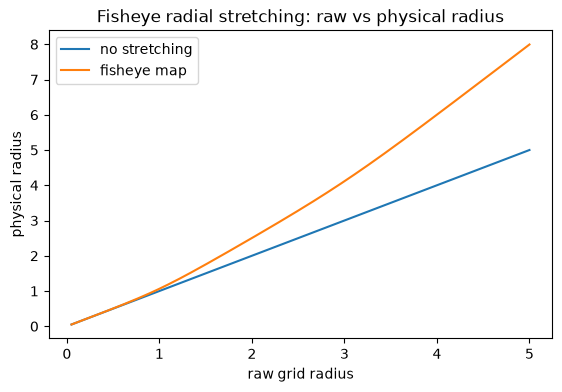

In [3]:
substitutions = {
    fisheye_map.a_list[0]: sp.Rational(1, 1),
    fisheye_map.a_list[1]: sp.Rational(3, 2),
    fisheye_map.a_list[2]: sp.Rational(2, 1),
    fisheye_map.R_list[0]: sp.Rational(1, 1),
    fisheye_map.R_list[1]: sp.Rational(3, 1),
    fisheye_map.s_list[0]: sp.Rational(2, 5),
    fisheye_map.s_list[1]: sp.Rational(7, 10),
    fisheye_map.c: sp.Rational(1, 1),
}
sampled_radii = []
for raw_radius_value in [sp.Rational(1, 4), 1, 2, 4]:
    value = fisheye_map.rbar_unscaled.subs(
        {
            fisheye_map.xx[0]: raw_radius_value,
            fisheye_map.xx[1]: 0,
            fisheye_map.xx[2]: 0,
            **substitutions,
        }
    )
    ratio = sp.simplify(value / raw_radius_value)
    sampled_radii.append((raw_radius_value, value, ratio))
print("raw radius | physical radius | physical/raw")
for raw_radius_value, value, ratio in sampled_radii:
    print(raw_radius_value, "|", sp.N(value, 12), "|", sp.N(ratio, 8))

radial_expr = fisheye_map.rbar_unscaled.subs(
    {fisheye_map.xx[1]: 0, fisheye_map.xx[2]: 0, **substitutions}
)
radius_map = sp.lambdify(fisheye_map.xx[0], radial_expr, "numpy")
raw_samples = np.linspace(0.05, 5.0, 200)
physical_samples = radius_map(raw_samples)
plt.figure(figsize=(6.5, 4))
plt.plot(raw_samples, raw_samples, label="no stretching")
plt.plot(raw_samples, physical_samples, label="fisheye map")
plt.xlabel("raw grid radius")
plt.ylabel("physical radius")
plt.title("Fisheye radial stretching: raw vs physical radius")
plt.legend()
plt.show()

The sample ratios increase across the chosen transition region. The plotted
fisheye curve lies above the no-stretching diagonal after the transitions,
showing that equal raw grid spacing corresponds to larger physical spacing
there.

# Validation Check
### [Back to [top](#Table-of-Contents)]

The trusted result is the metric induced from the Cartesian map. The newly
computed result is `fisheye_map.ghatDD`. The residual table covers all six
independent components of the symmetric metric.

In [4]:
metric_residuals = []
print("component | induced metric residual")
for i in range(3):
    for j in range(i, 3):
        induced_metric_ij = sum(
            fisheye_map.dCart_dxxUD[k][i] * fisheye_map.dCart_dxxUD[k][j]
            for k in range(3)
        )
        residual = sp.simplify(fisheye_map.ghatDD[i][j] - induced_metric_ij)
        metric_residuals.append(residual)
        print(f"({i}, {j}) |", residual)
if any(residual != 0 for residual in metric_residuals):
    raise RuntimeError("Expected all independent metric residuals to vanish.")
print("validation status: induced metric residuals passed")

component | induced metric residual


(0, 0) | 0


(0, 1) | 0


(0, 2) | 0


(1, 1) | 0


(1, 2) | 0


(2, 2) | 0
validation status: induced metric residuals passed


# Step 4: Validate Generated Support Functions
### [Back to [top](#Table-of-Contents)]

The metric residuals above check the mathematics of the induced reference
metric. The generated-support check below verifies that GeneralRFM registered
this as a two-transition fisheye map and that the expected generated support
functions exist.

Inspect the complete generated-function catalog:

| Generated function | Purpose | What to inspect |
| --- | --- | --- |
| `generalrfm_precompute__rfm__GeneralRFM_fisheyeN2` | metric data | wrapper |
| `generalrfm_Cart_to_xx__GeneralRFM_fisheyeN2` | inverse coordinates | return |
| `fisheye_params_from_physical_N2` | physical inputs | parameters |

This cell checks the provider metadata in the current kernel before the
subprocess performs the isolated generated-function registration.

In [5]:
if rfm.general_rfm_provider_name != "fisheye":
    raise RuntimeError("Expected the GeneralRFM provider to be fisheye.")
if rfm.general_rfm_provider_meta != {"num_transitions": 2}:
    raise RuntimeError("Expected a two-transition fisheye provider.")
print("provider check:", rfm.general_rfm_provider_name, rfm.general_rfm_provider_meta)

provider check: fisheye {'num_transitions': 2}


The next code cell defines the subprocess script. Skim this helper
scaffolding; it exists only to isolate global NRPy registration state. The
following cell runs it and prints the required evidence.

In [6]:
support_script = r"""
import nrpy.c_function as cfc
import nrpy.params as par
import nrpy.reference_metric as refmetric
from nrpy.equations.generalrfm import fisheye
from nrpy.infrastructures.BHaH import generalrfm_precompute
from nrpy.infrastructures.BHaH.fisheye import phys_params_to_fisheye

par.set_parval_from_str("parallelization", "openmp")
par.set_parval_from_str("fp_type", "double")
fisheye.build_fisheye(2)
rfm = refmetric.reference_metric["GeneralRFM_fisheyeN2"]
if rfm.general_rfm_provider_name != "fisheye":
    raise SystemExit("GeneralRFM provider was not fisheye")
if rfm.general_rfm_provider_meta != {"num_transitions": 2}:
    raise SystemExit("GeneralRFM provider did not record two transitions")
cfc.CFunction_dict.clear()
generalrfm_precompute.register_CFunctions_generalrfm_support(
    "GeneralRFM_fisheyeN2"
)
phys_params_to_fisheye.register_CFunction_fisheye_params_from_physical_N(2)
expected = [
    "generalrfm_precompute__rfm__GeneralRFM_fisheyeN2",
    "generalrfm_Cart_to_xx__GeneralRFM_fisheyeN2",
    "fisheye_params_from_physical_N2",
]
registered = set(cfc.CFunction_dict)
missing = sorted(set(expected) - registered)
extra = sorted(registered - set(expected))
print("expected functions:", expected)
print("missing functions:", missing)
print("extra functions:", extra)
if missing or extra:
    raise SystemExit("generated support function set did not match expectation")
for name in expected:
    cfunc = cfc.CFunction_dict[name]
    print("generated function:", name)
    print("  return type:", cfunc.cfunc_type)
    print("  includes:", cfunc.includes)
    print("  coordinate wrapper:", cfunc.CoordSystem_for_wrapper_func or "None")
    print("  include_CodeParameters_h:", cfunc.include_CodeParameters_h)
    print("  body length:", len(cfunc.body))
    print("  parameter list:")
    print(cfunc.params)
    print("  complete prototype:")
    print(cfunc.function_prototype)
print("validation status: generated GeneralRFM support passed")
"""

The output below prints the expected function set, missing and extra names,
complete metadata, and complete prototypes. This is the generated-code
validation evidence for the GeneralRFM support registry.

In [7]:
import subprocess
import sys
import textwrap

result = subprocess.run(
    [sys.executable, "-c", textwrap.dedent(support_script)],
    text=True,
    capture_output=True,
    check=False,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Generated fisheye support validation failed.")

Setting up reference_metric[GeneralRFM_fisheyeN2]...
expected functions: ['generalrfm_precompute__rfm__GeneralRFM_fisheyeN2', 'generalrfm_Cart_to_xx__GeneralRFM_fisheyeN2', 'fisheye_params_from_physical_N2']
missing functions: []
extra functions: []
generated function: generalrfm_precompute__rfm__GeneralRFM_fisheyeN2
  return type: void
  includes: ['BHaH_defines.h', 'BHaH_function_prototypes.h']
  coordinate wrapper: GeneralRFM_fisheyeN2
  include_CodeParameters_h: True
  body length: 9503
  parameter list:
const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL *restrict xx[3], REAL *restrict auxevol_gfs
  complete prototype:
void generalrfm_precompute__rfm__GeneralRFM_fisheyeN2(const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL *restrict xx[3], REAL *restrict auxevol_gfs);
generated function: generalrfm_Cart_to_xx__GeneralRFM_fisheyeN2
  return type: int
  includes: ['BHaH_defines.h', 'BHaH_function_p

The samples and plot show where raw and physical radius differ. The metric
residuals validate the induced reference metric. The provider metadata and
generated CFunction metadata show how GeneralRFM carries the map into the
generated-code path used by BHaH projects.

# Learning Check
### [Back to [top](#Table-of-Contents)]

Use one sample row and one feature of the plot to identify where raw and
physical radius differ most. Explain how that difference indicates where
resolution is concentrated or spread out.

# Continue
### [Back to [top](#Table-of-Contents)]

- [Reference-Metric Applications](reference_metric_applications.ipynb)
- [Curvilinear Boundary Conditions](curvilinear_boundary_conditions.ipynb)
- [Multicoordinate Wave Project](../3-wave_equation/wave_equation_multicoordinates.ipynb)